In [1]:

# ── CELL 1 ── Imports, seed, device
import os, sys, json, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
from collections import defaultdict
from pathlib import Path

import cv2
import torch
import torchvision.transforms as T
from PIL import Image as PILImage
from ultralytics import YOLO as UltralyticsYOLO

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops, hog
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    classification_report
)
import joblib

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# Device: MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

CLASS_NAMES = ["BIODEGRADABLE", "CARDBOARD", "GLASS", "METAL", "PAPER", "PLASTIC"]

print(f"Device : {DEVICE}")
print(f"Classes: {CLASS_NAMES}")
print("Imports OK — E11 Domain-Adapted")


Device : mps
Classes: ['BIODEGRADABLE', 'CARDBOARD', 'GLASS', 'METAL', 'PAPER', 'PLASTIC']
Imports OK — E11 Domain-Adapted


In [2]:

# ── CELL 2 ── Repo root + all paths
_local = os.path.expanduser("~/Desktop/CV-Project")
_colab = "/content/drive/MyDrive/CV/repo"

if os.path.isdir(_colab):
    REPO_ROOT = _colab
elif os.path.isdir(_local):
    REPO_ROOT = _local
else:
    REPO_ROOT = os.getcwd()

FEAT_DIR    = os.path.join(REPO_ROOT, "data", "processed", "features")
TRAIN_IMG   = os.path.join(FEAT_DIR, "train", "images")
TRAIN_LBL   = os.path.join(FEAT_DIR, "train", "labels")
TEST_IMG    = os.path.join(FEAT_DIR, "test",  "images")
TEST_LBL    = os.path.join(FEAT_DIR, "test",  "labels")
MODELS_DIR  = os.path.join(REPO_ROOT, "models")
RESULTS_DIR = os.path.join(REPO_ROOT, "results", "metrics")
FIGS_DIR    = os.path.join(REPO_ROOT, "figures", "detection")
# Checkpoints: allow restart at any stage without re-running YOLO
CKPT_DIR    = os.path.join(REPO_ROOT, "data", "processed", "da_checkpoints")

YOLO_WEIGHTS      = os.path.join(FEAT_DIR, "yolov8n_E1_best.pt")
MATCHED_JSON      = os.path.join(CKPT_DIR, "da_matched_train.json")      # Stage 1 out: predicted crops
UNMATCHED_GT_JSON = os.path.join(CKPT_DIR, "da_unmatched_gt.json")       # Stage 1 out: missed GT boxes
MERGED_JSON       = os.path.join(CKPT_DIR, "da_matched_merged.json")     # Stage 7b out: predicted + jitter
YOLO_FEAT_NPY     = os.path.join(CKPT_DIR, "da_yolo_train_X.npy")
CLAS_FEAT_NPY     = os.path.join(CKPT_DIR, "da_classical_train_X.npy")
LABELS_NPY        = os.path.join(CKPT_DIR, "da_train_y.npy")

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGS_DIR,    exist_ok=True)
os.makedirs(CKPT_DIR,    exist_ok=True)

# Verify everything exists before starting expensive computation
checks = [
    (TRAIN_IMG,    "Train images dir"),
    (TRAIN_LBL,    "Train labels dir"),
    (TEST_IMG,     "Test  images dir"),
    (TEST_LBL,     "Test  labels dir"),
    (YOLO_WEIGHTS, "YOLO  weights"),
]
for path, label in checks:
    assert os.path.exists(path), f"NOT FOUND: {label} → {path}"
    print(f"✓  {label}: {path}")

print(f"\nCheckpoint dir: {CKPT_DIR}")
print("All paths verified.")



✓  Train images dir: /Users/nadaashraf/Desktop/CV-Project/data/processed/features/train/images
✓  Train labels dir: /Users/nadaashraf/Desktop/CV-Project/data/processed/features/train/labels
✓  Test  images dir: /Users/nadaashraf/Desktop/CV-Project/data/processed/features/test/images
✓  Test  labels dir: /Users/nadaashraf/Desktop/CV-Project/data/processed/features/test/labels
✓  YOLO  weights: /Users/nadaashraf/Desktop/CV-Project/data/processed/features/yolov8n_E1_best.pt

Checkpoint dir: /Users/nadaashraf/Desktop/CV-Project/data/processed/da_checkpoints
All paths verified.


In [3]:

# ── CELL 3 ── Baseline constants
# E1 (YOLO end-to-end, fully trained) and E11-original (GT-trained SVM, domain-naive)
# are the two benchmarks E11-DA must beat to justify domain adaptation.

E1_MAP50   = 0.4559
E11_MAP50  = 0.3840   # E11-original (domain-naive)

E1_PER_CLASS = {
    "BIODEGRADABLE": 0.4663,
    "CARDBOARD":     0.4445,
    "GLASS":         0.4575,
    "METAL":         0.5161,
    "PAPER":         0.3939,
    "PLASTIC":       0.4572,
}
E11_PER_CLASS = {
    "BIODEGRADABLE": 0.4441,
    "CARDBOARD":     0.3915,
    "GLASS":         0.3826,
    "METAL":         0.4065,
    "PAPER":         0.3256,
    "PLASTIC":       0.3537,
}

# Detection thresholds — locked to E1 and E11-original for fair comparison
YOLO_CONF_THRESH = 0.25
YOLO_IOU_THRESH  = 0.45
# IoU threshold for matching a predicted train box to a GT label during domain adaptation
GT_MATCH_IOU     = 0.50   # PASCAL VOC standard

print(f"E1  baseline  mAP@0.5 : {E1_MAP50}")
print(f"E11 domain-naive mAP@0.5 : {E11_MAP50}  ← must exceed this")
print(f"GT match IoU threshold  : {GT_MATCH_IOU}")


E1  baseline  mAP@0.5 : 0.4559
E11 domain-naive mAP@0.5 : 0.384  ← must exceed this
GT match IoU threshold  : 0.5


In [13]:
# ── CELL 4 ── Load YOLO + SPPF forward hook
# Same model is used for:
#   (a) Bounding box detection (ultralytics API)
#   (b) SPPF feature extraction (PyTorch hook on backbone layer 9)

yolo_detector = UltralyticsYOLO(YOLO_WEIGHTS)
yolo_detector.model.eval()
yolo_detector.model.to(DEVICE)
nn_backbone = yolo_detector.model

# Hook fires on SPPF (layer 9 of YOLOv8n backbone)
_sppf_buf    = {}
_sppf_handle = nn_backbone.model[9].register_forward_hook(
    lambda m, inp, out: _sppf_buf.update({"feat": out.detach()})
)

# YOLO preprocessing: ToTensor only (/255), NO ImageNet mean/std
_to_tensor = T.Compose([T.ToTensor()])

def extract_sppf(crop_rgb_224: np.ndarray) -> np.ndarray:
    """
    Forward a 224×224 RGB uint8 crop through YOLOv8n backbone.
    Global Average Pools the SPPF output [1, 256, H', W'] → (256,).

    nn_backbone and yolo_detector.model are the same object. ultralytics moves
    model weights between devices during predict(). We detect the current device
    from the model parameters and send the tensor there — never force .to(DEVICE)
    which would conflict with ultralytics on the next predict() call.
    """
    current_device = next(nn_backbone.parameters()).device
    t = _to_tensor(PILImage.fromarray(crop_rgb_224)).unsqueeze(0).to(current_device)
    with torch.no_grad():
        nn_backbone(t)
    return _sppf_buf["feat"].mean(dim=[2, 3]).cpu().numpy().flatten()  # (256,)

# Smoke test
_dummy = np.zeros((224, 224, 3), dtype=np.uint8)
assert extract_sppf(_dummy).shape == (256,), "SPPF output shape wrong"
print("YOLO loaded — SPPF hook on model[9] — output shape (256,) ✓")


YOLO loaded — SPPF hook on model[9] — output shape (256,) ✓


In [5]:

# ── CELL 5 ── Classical feature extractor (252-dim, exact E2 pipeline)
# Verbatim copy of src/features/classical_features.py
# Components: Color (96) + LBP (26) + Gabor (48) + HOG (36) + Shape (10) + GLCM (36) = 252

def _color_histogram(img_rgb: np.ndarray, bins: int = 32) -> np.ndarray:
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    feats = []
    for ch in range(3):
        hist, _ = np.histogram(img_hsv[:, :, ch], bins=bins, range=(0, 256), density=True)
        feats.append(hist)
    return np.concatenate(feats)   # 96

def _lbp(gray: np.ndarray, n_points: int = 24, radius: int = 3) -> np.ndarray:
    lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=n_points + 2,
                           range=(0, n_points + 2), density=True)
    return hist   # 26

def _gabor(gray: np.ndarray) -> np.ndarray:
    feats = []
    for freq in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:         # 6 freq
        for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:   # 4 orient
            kernel = cv2.getGaborKernel(
                (21, 21), 5, theta, 1 / freq, 0.5, 0, ktype=cv2.CV_32F
            )
            filtered = cv2.filter2D(gray.astype(np.float32), cv2.CV_32F, kernel)
            feats.extend([filtered.mean(), filtered.std()])
    return np.array(feats)   # 6 × 4 × 2 = 48

def _hog_feats(gray: np.ndarray) -> np.ndarray:
    feats = hog(gray, orientations=9, pixels_per_cell=(8, 8),
                cells_per_block=(2, 2), feature_vector=True)
    target = 36
    if len(feats) >= target:
        return feats[:target]
    return np.pad(feats, (0, target - len(feats)))   # 36

def _shape(gray: np.ndarray) -> np.ndarray:
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros(10)
    cnt     = max(contours, key=cv2.contourArea)
    area    = cv2.contourArea(cnt)
    perim   = cv2.arcLength(cnt, True)
    x, y, w, h = cv2.boundingRect(cnt)
    aspect  = w / (h + 1e-6)
    circ    = 4 * np.pi * area / (perim**2 + 1e-6)
    extent  = area / (w * h + 1e-6)
    hu      = cv2.HuMoments(cv2.moments(cnt)).flatten()
    return np.array([aspect, circ, extent, *hu[:7]])   # 10

def _glcm(gray: np.ndarray) -> np.ndarray:
    glcm = graycomatrix(
        gray, distances=[1, 3],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256, symmetric=True, normed=True
    )
    props = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]
    raw = np.concatenate([graycoprops(glcm, p).ravel() for p in props])
    return raw[:36]   # trim 5×2×4=40 → 36

def extract_classical(img_rgb_224: np.ndarray) -> np.ndarray:
    """252-dim classical feature vector from a 224×224 RGB uint8 array."""
    gray  = cv2.cvtColor(img_rgb_224, cv2.COLOR_RGB2GRAY)
    feats = np.concatenate([
        _color_histogram(img_rgb_224),  # 96
        _lbp(gray),                     # 26
        _gabor(gray),                   # 48
        _hog_feats(gray),               # 36
        _shape(gray),                   # 10
        _glcm(gray),                    # 36
    ])
    assert len(feats) == 252, f"Classical dim: expected 252, got {len(feats)}"
    return feats

assert extract_classical(_dummy).shape == (252,), "Classical output shape wrong"
print("Classical extractor OK — output shape (252,) ✓")


Classical extractor OK — output shape (252,) ✓


In [6]:

# ── CELL 6 ── Utility functions
def box_iou(a: list, b: list) -> float:
    """IoU between two [x1,y1,x2,y2] boxes in pixel coordinates."""
    xi1 = max(a[0], b[0])
    yi1 = max(a[1], b[1])
    xi2 = min(a[2], b[2])
    yi2 = min(a[3], b[3])
    inter = max(0.0, xi2 - xi1) * max(0.0, yi2 - yi1)
    if inter == 0.0:
        return 0.0
    a_area = (a[2] - a[0]) * (a[3] - a[1])
    b_area = (b[2] - b[0]) * (b[3] - b[1])
    return inter / (a_area + b_area - inter + 1e-6)

def parse_gt(label_path: str, img_w: int, img_h: int) -> list:
    """
    Parse a YOLO-format .txt label file.
    Returns list of (class_id, x1, y1, x2, y2) in absolute pixel coordinates.
    """
    boxes = []
    if not os.path.isfile(label_path):
        return boxes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cls = int(parts[0])
            xc, yc, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x1 = (xc - w / 2) * img_w
            y1 = (yc - h / 2) * img_h
            x2 = (xc + w / 2) * img_w
            y2 = (yc + h / 2) * img_h
            boxes.append((cls, x1, y1, x2, y2))
    return boxes

def safe_crop_resize(img_rgb: np.ndarray, x1: float, y1: float,
                     x2: float, y2: float, size: int = 224):
    """
    Crop a predicted bounding box from a full image, clamp to image bounds,
    resize to size×size RGB uint8. Returns None if crop is too small to be valid.
    """
    H, W = img_rgb.shape[:2]
    x1c, y1c = max(0, int(x1)), max(0, int(y1))
    x2c, y2c = min(W, int(x2)), min(H, int(y2))
    if x2c <= x1c or y2c <= y1c:
        return None
    if min(x2c - x1c, y2c - y1c) < 8:   # smaller than 8×8 is not meaningful
        return None
    crop = img_rgb[y1c:y2c, x1c:x2c]
    if crop.size == 0:
        return None
    return cv2.resize(crop, (size, size), interpolation=cv2.INTER_LINEAR)

print("Utilities ready: box_iou, parse_gt, safe_crop_resize")


Utilities ready: box_iou, parse_gt, safe_crop_resize


In [7]:

# ── CELL 7 ── STAGE 1 — YOLO inference on training images → GT matching → checkpoint JSON
#
# For each training image:
#   1. Run YOLOv8n to get predicted bounding boxes
#   2. For each predicted box, find the GT box with highest IoU
#   3. If best IoU ≥ 0.50 → matched sample (source="predicted")
#   4. GT boxes that received no matching prediction → unmatched_gt (fed to jitter in Cell 7b)
#
# Two checkpoints saved: da_matched_train.json + da_unmatched_gt.json
# Both must exist to skip this cell on restart.

if os.path.isfile(MATCHED_JSON) and os.path.isfile(UNMATCHED_GT_JSON):
    print(f"Stage 1 checkpoint found — loading both JSON files…")
    with open(MATCHED_JSON) as f:
        matched_samples = json.load(f)
    with open(UNMATCHED_GT_JSON) as f:
        unmatched_gt = json.load(f)
    print(f"  Predicted matched : {len(matched_samples):,}")
    print(f"  GT missed (unmatched): {len(unmatched_gt):,}  → fed to jitter in Cell 7b")

else:
    print("Stage 1: Running YOLO on training images…")

    train_img_paths = sorted(
        list(Path(TRAIN_IMG).glob("*.jpg")) + list(Path(TRAIN_IMG).glob("*.png"))
    )
    print(f"Training images found: {len(train_img_paths)}")

    matched_samples  = []
    unmatched_gt     = []   # GT boxes YOLO missed — will be jitter-filled in Cell 7b
    total_preds      = 0
    fp_discarded     = 0    # predicted boxes with no GT match (false positives)
    class_counts_det = defaultdict(int)
    t0 = time.time()

    for i, img_path in enumerate(train_img_paths):
        results  = yolo_detector.predict(
            str(img_path),
            conf=YOLO_CONF_THRESH,
            iou=YOLO_IOU_THRESH,
            verbose=False,
            save=False,
        )
        result       = results[0]
        img_h, img_w = result.orig_shape

        lbl_path = os.path.join(TRAIN_LBL, img_path.stem + ".txt")
        gt_boxes = parse_gt(lbl_path, img_w, img_h)

        if not gt_boxes:
            continue

        # Track which GT boxes get claimed by any predicted box
        gt_matched = [False] * len(gt_boxes)

        if result.boxes is not None and len(result.boxes) > 0:
            for det in result.boxes:
                px1, py1, px2, py2 = det.xyxy[0].cpu().numpy().tolist()
                yolo_conf = float(det.conf[0].cpu().numpy())
                total_preds += 1

                best_iou, best_cls, best_gt_idx = 0.0, None, -1
                for gt_idx, (gt_cls, gx1, gy1, gx2, gy2) in enumerate(gt_boxes):
                    iou_val = box_iou([px1, py1, px2, py2], [gx1, gy1, gx2, gy2])
                    if iou_val > best_iou:
                        best_iou, best_cls, best_gt_idx = iou_val, gt_cls, gt_idx

                if best_iou >= GT_MATCH_IOU:
                    matched_samples.append({
                        "image":     str(img_path),
                        "bbox":      [px1, py1, px2, py2],
                        "yolo_conf": yolo_conf,
                        "iou":       best_iou,
                        "label":     int(best_cls),
                        "source":    "predicted",
                    })
                    gt_matched[best_gt_idx] = True
                    class_counts_det[int(best_cls)] += 1
                else:
                    fp_discarded += 1

        # Any GT box with no matching prediction → feed to jitter fill
        for gt_idx, was_matched in enumerate(gt_matched):
            if not was_matched:
                gt_cls, gx1, gy1, gx2, gy2 = gt_boxes[gt_idx]
                unmatched_gt.append({
                    "image": str(img_path),
                    "bbox":  [gx1, gy1, gx2, gy2],
                    "label": int(gt_cls),
                    "img_w": int(img_w),
                    "img_h": int(img_h),
                })

        if (i + 1) % 500 == 0:
            elapsed = time.time() - t0
            print(f"  [{i+1}/{len(train_img_paths)}]  "
                  f"matched={len(matched_samples):,}  "
                  f"missed_gt={len(unmatched_gt):,}  "
                  f"elapsed={elapsed:.0f}s")

    elapsed = time.time() - t0
    miss_rate = len(unmatched_gt) / max(len(unmatched_gt) + sum(gt_matched), 1) * 100

    print(f"\nStage 1 complete in {elapsed:.0f}s ({elapsed/60:.1f} min)")
    print(f"  Total YOLO predictions    : {total_preds:,}")
    print(f"  Predicted matched         : {len(matched_samples):,}")
    print(f"  Predicted FP (discarded)  : {fp_discarded:,}")
    print(f"  GT boxes YOLO missed      : {len(unmatched_gt):,}  → will be jitter-filled")
    print(f"\nPer-class predicted matched counts:")
    for cls_id, name in enumerate(CLASS_NAMES):
        cnt = class_counts_det[cls_id]
        print(f"  {name:<18}: {cnt:>6,}")

    with open(MATCHED_JSON, "w") as f:
        json.dump(matched_samples, f)
    with open(UNMATCHED_GT_JSON, "w") as f:
        json.dump(unmatched_gt, f)
    print(f"\nCheckpoints saved:")
    print(f"  {MATCHED_JSON}")
    print(f"  {UNMATCHED_GT_JSON}")
    print("Re-run from Cell 7b to apply jitter — YOLO inference will not repeat.")



Stage 1 checkpoint found — loading both JSON files…
  Predicted matched : 32,155
  GT missed (unmatched): 19,786  → fed to jitter in Cell 7b


In [8]:

# ── CELL 7b ── JITTER FILL — synthesise crops for YOLO-missed GT boxes
#
# YOLO's recall ≈ 0.50 means ~half of all GT objects on training images were never
# detected, so E11-DA Stage 1 only recovers ~22–28K samples out of ~45K GT crops.
# The missed GT boxes leave holes in the training distribution — certain hard or
# small objects are systematically absent.
#
# Jitter fill closes that gap: for each missed GT box, we synthetically perturb it
# (random translation ±20%, scale 0.80–1.25, mild aspect change 0.90–1.10) to
# produce a crop that mimics what a real detector might have predicted.
# The jitter magnitude is calibrated so the resulting box has IoU 0.50–0.80 with
# the original GT box — matching the typical IoU range of YOLO's true positive
# detections.
#
# Result: matched_samples becomes predicted_crops UNION jittered_GT_fills,
# giving ~full 45K coverage at the cost of synthetic (rather than real) noise
# for the missed half.
#
# Checkpoint: if da_matched_merged.json exists, skip jitter and load merged set.

def jitter_box(x1: float, y1: float, x2: float, y2: float,
               img_w: int, img_h: int,
               target_iou_min: float = 0.50,
               target_iou_max: float = 0.80,
               max_attempts:   int   = 40) -> tuple:
    """
    Perturb a GT box with random translation + scale + mild aspect change.
    Returns (jx1, jy1, jx2, jy2) whose IoU with the original is in
    [target_iou_min, target_iou_max], or None if no valid jitter found.

    Jitter parameters chosen to replicate real YOLO localization error:
      - Translation: ±20% of box width/height (shifts center)
      - Scale factor: Uniform[0.80, 1.25] (simulates over/under-detection area)
      - Aspect ratio: Uniform[0.90, 1.10] (mild width/height imbalance)
    These jointly produce IoU values in the 0.50–0.80 range typical of
    YOLO's true positive detections on this dataset (E1 eval).
    """
    w  = x2 - x1
    h  = y2 - y1
    cx = (x1 + x2) / 2.0
    cy = (y1 + y2) / 2.0

    for _ in range(max_attempts):
        tx    = np.random.uniform(-0.20, 0.20) * w
        ty    = np.random.uniform(-0.20, 0.20) * h
        scale = np.random.uniform(0.80, 1.25)
        ar    = np.random.uniform(0.90, 1.10)

        new_w = w * scale * ar
        new_h = h * scale / ar
        jx1   = max(0.0, cx + tx - new_w / 2.0)
        jy1   = max(0.0, cy + ty - new_h / 2.0)
        jx2   = min(float(img_w), cx + tx + new_w / 2.0)
        jy2   = min(float(img_h), cy + ty + new_h / 2.0)

        if jx2 <= jx1 or jy2 <= jy1:
            continue
        if min(jx2 - jx1, jy2 - jy1) < 8:
            continue

        iou_val = box_iou([jx1, jy1, jx2, jy2], [x1, y1, x2, y2])
        if target_iou_min <= iou_val <= target_iou_max:
            return jx1, jy1, jx2, jy2

    return None   # exhausted max_attempts without hitting target IoU range


if os.path.isfile(MERGED_JSON):
    print(f"Jitter checkpoint found — loading merged set: {MERGED_JSON}")
    with open(MERGED_JSON) as f:
        matched_samples = json.load(f)
    n_pred   = sum(1 for s in matched_samples if s.get("source") == "predicted")
    n_jitter = sum(1 for s in matched_samples if s.get("source") == "jitter")
    print(f"  Predicted crops : {n_pred:,}")
    print(f"  Jitter fills    : {n_jitter:,}")
    print(f"  Total merged    : {len(matched_samples):,}")

else:
    print(f"Stage 1b — Jitter fill for {len(unmatched_gt):,} YOLO-missed GT boxes…")
    n_predicted = len(matched_samples)   # count before merge

    jitter_fills        = []
    jitter_failed       = 0
    jitter_class_counts = defaultdict(int)

    for gt_sample in unmatched_gt:
        gx1, gy1, gx2, gy2 = gt_sample["bbox"]
        img_w = gt_sample["img_w"]
        img_h = gt_sample["img_h"]
        label = gt_sample["label"]

        result = jitter_box(gx1, gy1, gx2, gy2, img_w, img_h)
        if result is None:
            jitter_failed += 1
            continue

        jx1, jy1, jx2, jy2 = result
        jitter_fills.append({
            "image":     gt_sample["image"],
            "bbox":      [jx1, jy1, jx2, jy2],
            "yolo_conf": -1.0,    # no real detection confidence — not used in feature extraction
            "iou":       -1.0,
            "label":     label,
            "source":    "jitter",
        })
        jitter_class_counts[label] += 1

    matched_samples = matched_samples + jitter_fills   # merge

    print(f"\nJitter fill complete:")
    print(f"  Predicted matched  : {n_predicted:,}")
    print(f"  Jitter fills added : {len(jitter_fills):,}")
    print(f"  Jitter failed      : {jitter_failed}  (too small or IoU target unachievable)")
    print(f"  Total merged       : {len(matched_samples):,}")
    print(f"\nPer-class distribution after merge (predicted | jitter | total):")
    pred_by_cls   = defaultdict(int)
    jitter_by_cls = defaultdict(int)
    for s in matched_samples:
        if s["source"] == "predicted":
            pred_by_cls[s["label"]] += 1
        else:
            jitter_by_cls[s["label"]] += 1
    for cls_id, name in enumerate(CLASS_NAMES):
        p = pred_by_cls[cls_id]
        j = jitter_by_cls[cls_id]
        print(f"  {name:<18}: {p:>6,} pred  +  {j:>6,} jitter  =  {p+j:>6,}")

    with open(MERGED_JSON, "w") as f:
        json.dump(matched_samples, f)
    print(f"\nMerged checkpoint saved → {MERGED_JSON}")
    print("Re-run from Cell 8 — jitter will not repeat.")


Jitter checkpoint found — loading merged set: /Users/nadaashraf/Desktop/CV-Project/data/processed/da_checkpoints/da_matched_merged.json
  Predicted crops : 32,155
  Jitter fills    : 19,477
  Total merged    : 51,632


In [9]:

# ── CELL 8 ── STAGE 2 — Feature extraction from matched predicted crops
#
# For each sample in matched_samples (source="predicted" OR source="jitter"):
#   1. Load the training image from disk
#   2. Crop the bbox region (predicted or jittered — same code path)
#   3. Resize to 224×224 — identical to E11-original training and inference
#   4. Extract 256-dim SPPF + 252-dim Classical features
#
# Jitter and predicted samples go through the exact same extraction pipeline.
# Their difference is only in crop content, not in processing.
#
# Checkpoint: if .npy files exist, skip extraction and load directly.

if all(os.path.isfile(p) for p in [YOLO_FEAT_NPY, CLAS_FEAT_NPY, LABELS_NPY]):
    print("Stage 2 checkpoint found — loading feature arrays…")
    X_yolo_da = np.load(YOLO_FEAT_NPY)
    X_clas_da = np.load(CLAS_FEAT_NPY)
    y_da      = np.load(LABELS_NPY)
    print(f"Loaded YOLO  : {X_yolo_da.shape}")
    print(f"Loaded Clas  : {X_clas_da.shape}")
    print(f"Loaded Labels: {y_da.shape}")

else:
    n_samples = len(matched_samples)
    print(f"Stage 2: Extracting features from {n_samples:,} matched crops…")
    print("Estimated time: 10–20 min locally (classical Gabor filters dominate).")
    print("Progress reported every 1000 crops.\n")

    X_yolo_list, X_clas_list, y_list = [], [], []
    skipped        = 0
    skip_no_image  = 0   # cv2.imread returned None
    skip_bad_crop  = 0   # crop too small / empty
    skip_feat_err  = 0   # feature extraction exception
    _err_log       = []  # first 5 skip reasons for diagnosis
    t0             = time.time()

    for i, sample in enumerate(matched_samples):
        # Load full image from disk
        img_bgr = cv2.imread(sample["image"])
        if img_bgr is None:
            skip_no_image += 1
            skipped       += 1
            if len(_err_log) < 5:
                _err_log.append(f"cv2.imread returned None: {sample['image']}")
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # Crop predicted / jitter bbox and resize to 224×224
        crop = safe_crop_resize(img_rgb, *sample["bbox"])
        if crop is None:
            skip_bad_crop += 1
            skipped       += 1
            if len(_err_log) < 5:
                _err_log.append(f"bad crop bbox={sample['bbox']} in {sample['image']}")
            continue

        # Extract features — same pipelines as E11-original
        try:
            sppf_feat = extract_sppf(crop)       # (256,)
            clas_feat = extract_classical(crop)   # (252,)
        except Exception as e:
            skip_feat_err += 1
            skipped       += 1
            if len(_err_log) < 5:
                _err_log.append(f"feature error ({type(e).__name__}: {e})")
            continue

        X_yolo_list.append(sppf_feat)
        X_clas_list.append(clas_feat)
        y_list.append(sample["label"])

        if (i + 1) % 1000 == 0:
            elapsed = time.time() - t0
            rate    = (i + 1) / elapsed
            eta     = (n_samples - i - 1) / max(rate, 1e-6)
            print(f"  [{i+1}/{n_samples}]  "
                  f"ok={len(y_list):,}  skip={skipped}  "
                  f"rate={rate:.1f}/s  ETA={eta:.0f}s ({eta/60:.1f} min)")

    # ── Diagnosis: if everything was skipped, surface the real reason ──
    if len(y_list) == 0:
        print("\n⚠  All samples were skipped. Skip breakdown:")
        print(f"   No image (imread=None) : {skip_no_image:,}")
        print(f"   Bad/tiny crop          : {skip_bad_crop:,}")
        print(f"   Feature extract error  : {skip_feat_err:,}")
        print("\nFirst skip reasons logged:")
        for reason in _err_log:
            print(f"   • {reason}")
        raise RuntimeError(
            "Feature extraction produced zero samples. "
            "Fix the root cause above, delete the .npy checkpoints if they exist, "
            "then re-run this cell."
        )

    X_yolo_da = np.array(X_yolo_list, dtype=np.float32)
    X_clas_da = np.array(X_clas_list, dtype=np.float32)
    y_da      = np.array(y_list,      dtype=np.int32)

    # Guard: drop any samples with NaN or Inf values (rare but possible with Gabor on edge crops)
    if X_yolo_da.ndim == 2 and X_clas_da.ndim == 2:
        finite_mask = (np.isfinite(X_yolo_da).all(axis=1) &
                       np.isfinite(X_clas_da).all(axis=1))
        n_bad = (~finite_mask).sum()
        if n_bad > 0:
            print(f"Dropping {n_bad} samples with NaN/Inf values")
            X_yolo_da = X_yolo_da[finite_mask]
            X_clas_da = X_clas_da[finite_mask]
            y_da      = y_da[finite_mask]

    elapsed = time.time() - t0
    print(f"\nStage 2 complete in {elapsed:.0f}s ({elapsed/60:.1f} min)")
    print(f"  Total crops processed : {n_samples:,}")
    print(f"  Successful            : {len(y_da):,}")
    print(f"  Skip — no image       : {skip_no_image:,}")
    print(f"  Skip — bad crop       : {skip_bad_crop:,}")
    print(f"  Skip — feature error  : {skip_feat_err:,}")

    np.save(YOLO_FEAT_NPY, X_yolo_da)
    np.save(CLAS_FEAT_NPY, X_clas_da)
    np.save(LABELS_NPY,    y_da)
    print(f"\nFeature checkpoints saved → {CKPT_DIR}")
    print("If SVM training fails, re-run from Cell 9 — features will not be re-extracted.")

# Distribution report
unique, counts = np.unique(y_da, return_counts=True)
print(f"\nDA training set: {len(y_da):,} samples")
print(f"  SPPF dim      : {X_yolo_da.shape[1]}")
print(f"  Classical dim : {X_clas_da.shape[1]}")
print(f"\nClass distribution (after domain adaptation):")
for cls_id, cnt in zip(unique, counts):
    print(f"  {CLASS_NAMES[cls_id]:<18}: {cnt:>6,}  ({cnt/len(y_da)*100:.1f}%)")



Stage 2: Extracting features from 51,632 matched crops…
Estimated time: 10–20 min locally (classical Gabor filters dominate).
Progress reported every 1000 crops.

  [1000/51632]  ok=1,000  skip=0  rate=19.2/s  ETA=2635s (43.9 min)
  [2000/51632]  ok=2,000  skip=0  rate=19.3/s  ETA=2566s (42.8 min)
  [3000/51632]  ok=3,000  skip=0  rate=19.4/s  ETA=2508s (41.8 min)
  [4000/51632]  ok=3,999  skip=1  rate=19.4/s  ETA=2455s (40.9 min)
  [5000/51632]  ok=4,999  skip=1  rate=19.4/s  ETA=2402s (40.0 min)
  [6000/51632]  ok=5,999  skip=1  rate=19.4/s  ETA=2347s (39.1 min)
  [7000/51632]  ok=6,998  skip=2  rate=19.5/s  ETA=2292s (38.2 min)
  [8000/51632]  ok=7,998  skip=2  rate=19.5/s  ETA=2240s (37.3 min)
  [9000/51632]  ok=8,998  skip=2  rate=19.5/s  ETA=2187s (36.5 min)
  [10000/51632]  ok=9,998  skip=2  rate=19.5/s  ETA=2135s (35.6 min)
  [11000/51632]  ok=10,997  skip=3  rate=19.5/s  ETA=2088s (34.8 min)
  [12000/51632]  ok=11,997  skip=3  rate=19.5/s  ETA=2037s (33.9 min)
  [13000/51632] 

In [10]:

# ── CELL 9 ── STAGE 3 — Train domain-adapted SVM
#
# Identical hyperparameters to E11-original:
#   SVM(RBF, C=10, gamma='scale', class_weight='balanced', probability=True)
# Feature space:
#   Per-modality StandardScaler → hstack → 508-dim (same as E11-original)
#
# The ONLY difference from E11-original: training data comes from predicted crops,
# not from the pre-extracted GT crop feature arrays.

print("Fitting per-modality StandardScalers…")
scaler_yolo_da = StandardScaler()
scaler_clas_da = StandardScaler()

X_yolo_s = scaler_yolo_da.fit_transform(X_yolo_da)
X_clas_s = scaler_clas_da.fit_transform(X_clas_da)

X_fused_da = np.hstack([X_yolo_s, X_clas_s])   # (N, 508)
print(f"Fused dim : {X_fused_da.shape[1]}  (YOLO 256 + Classical 252)")
print(f"Train size: {len(y_da):,}")

# Val sanity check using GT val crops
# NOTE: GT val crops are still from the original distribution (not domain-adapted val).
# This val score is a rough signal only — the primary metric is detection mAP on test set.
X_yolo_gt_val = np.load(os.path.join(FEAT_DIR, "yolo_val_X.npy"))
X_clas_gt_val = np.load(os.path.join(FEAT_DIR, "classical_val_X.npy"))
y_val         = np.load(os.path.join(FEAT_DIR, "classical_val_y.npy"))
X_val_fused = np.hstack([
    scaler_yolo_da.transform(X_yolo_gt_val),
    scaler_clas_da.transform(X_clas_gt_val),
])

print(f"\nTraining SVM(RBF, C=10, class_weight='balanced')…")
t0 = time.time()

svm_da = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=SEED,
    max_iter=5000,
)
svm_da.fit(X_fused_da, y_da)

fit_time = time.time() - t0
print(f"SVM training done in {fit_time:.0f}s ({fit_time/60:.1f} min)")

val_pred     = svm_da.predict(X_val_fused)
val_macro_f1 = f1_score(y_val, val_pred, average="macro")
val_acc      = accuracy_score(y_val, val_pred)
print(f"\nVal (GT crops) accuracy : {val_acc:.4f}")
print(f"Val (GT crops) macro-F1 : {val_macro_f1:.4f}")
print("(Val on GT crops is expected to differ from original E11 — distribution shift is intentional)")


Fitting per-modality StandardScalers…
Fused dim : 508  (YOLO 256 + Classical 252)
Train size: 51,624

Training SVM(RBF, C=10, class_weight='balanced')…
SVM training done in 980s (16.3 min)

Val (GT crops) accuracy : 0.8346
Val (GT crops) macro-F1 : 0.7215
(Val on GT crops is expected to differ from original E11 — distribution shift is intentional)


In [11]:

# ── CELL 10 ── Save domain-adapted models
svm_path    = os.path.join(MODELS_DIR, "e11_da_svm.pkl")
scalers_path = os.path.join(MODELS_DIR, "e11_da_scalers.pkl")

joblib.dump(svm_da, svm_path)
joblib.dump(
    {"scaler_yolo": scaler_yolo_da, "scaler_clas": scaler_clas_da},
    scalers_path
)

size_mb = os.path.getsize(svm_path) / 1e6
print(f"Saved SVM     : {svm_path}  ({size_mb:.1f} MB)")
print(f"Saved scalers : {scalers_path}")



Saved SVM     : /Users/nadaashraf/Desktop/CV-Project/models/e11_da_svm.pkl  (89.0 MB)
Saved scalers : /Users/nadaashraf/Desktop/CV-Project/models/e11_da_scalers.pkl


In [14]:

# ── CELL 11 ── STAGE 4 — Domain-adapted detection inference on test set
#
# Identical pipeline to E11-original Cell 9, except svm_da and domain-adapted
# scalers replace the GT-trained SVM and scalers.
# Confidence score: YOLO detection confidence (not SVM probability) — same as E1 and E11.

test_img_paths = sorted(
    list(Path(TEST_IMG).glob("*.jpg")) + list(Path(TEST_IMG).glob("*.png"))
)

all_preds_by_cls = defaultdict(list)   # cls → [(img_id, [x1,y1,x2,y2], yolo_conf)]
all_gt_by_cls    = defaultdict(list)   # cls → [(img_id, [x1,y1,x2,y2])]

n_agree    = 0
n_disagree = 0
total_det  = 0

print(f"Stage 4: Running DA two-stage detection on {len(test_img_paths)} test images…")
t0 = time.time()

for i, img_path in enumerate(test_img_paths):
    img_id = img_path.stem

    # ── YOLO: localization only ──
    results  = yolo_detector.predict(
        str(img_path),
        conf=YOLO_CONF_THRESH,
        iou=YOLO_IOU_THRESH,
        verbose=False,
        save=False,
    )
    result   = results[0]
    img_h, img_w = result.orig_shape

    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Collect GT boxes for mAP evaluation
    lbl_path = os.path.join(TEST_LBL, img_path.stem + ".txt")
    for (gt_cls, gx1, gy1, gx2, gy2) in parse_gt(lbl_path, img_w, img_h):
        all_gt_by_cls[gt_cls].append((img_id, [gx1, gy1, gx2, gy2]))

    if result.boxes is None or len(result.boxes) == 0:
        continue

    for det in result.boxes:
        x1, y1, x2, y2 = det.xyxy[0].cpu().numpy().tolist()
        yolo_conf  = float(det.conf[0].cpu().numpy())
        yolo_class = int(det.cls[0].cpu().numpy())
        total_det += 1

        # ── DA-SVM: classification only ──
        crop = safe_crop_resize(img_rgb, x1, y1, x2, y2)
        if crop is None:
            continue

        try:
            sppf_feat = extract_sppf(crop)
            clas_feat = extract_classical(crop)
        except Exception:
            continue

        sppf_s = scaler_yolo_da.transform(sppf_feat.reshape(1, -1))
        clas_s = scaler_clas_da.transform(clas_feat.reshape(1, -1))
        fused  = np.hstack([sppf_s, clas_s])

        svm_proba = svm_da.predict_proba(fused)[0]
        svm_cls   = int(np.argmax(svm_proba))

        if svm_cls == yolo_class:
            n_agree += 1
        else:
            n_disagree += 1

        # Confidence = YOLO detection score (not SVM probability)
        # Keeps comparison with E1 and E11-original fair
        all_preds_by_cls[svm_cls].append(
            (img_id, [x1, y1, x2, y2], yolo_conf)
        )

    if (i + 1) % 200 == 0:
        print(f"  [{i+1}/{len(test_img_paths)}]  "
              f"dets={total_det}  agree={n_agree}  disagree={n_disagree}")

elapsed    = time.time() - t0
agree_rate = n_agree / max(total_det, 1)

print(f"\nInference done in {elapsed:.0f}s")
print(f"Total detections  : {total_det}")
print(f"YOLO/DA-SVM agree : {n_agree} ({agree_rate*100:.1f}%)")
print(f"YOLO/DA-SVM differ: {n_disagree} ({(1-agree_rate)*100:.1f}%)")



Stage 4: Running DA two-stage detection on 1570 test images…
  [200/1570]  dets=2485  agree=2403  disagree=82
  [400/1570]  dets=4686  agree=4484  disagree=201
  [600/1570]  dets=5249  agree=4925  disagree=323
  [800/1570]  dets=5838  agree=5373  disagree=464
  [1000/1570]  dets=6546  agree=5891  disagree=654
  [1200/1570]  dets=7395  agree=6428  disagree=966
  [1400/1570]  dets=7748  agree=6695  disagree=1052

Inference done in 559s
Total detections  : 8341
YOLO/DA-SVM agree : 7111 (85.3%)
YOLO/DA-SVM differ: 1229 (14.7%)


In [15]:

# ── CELL 12 ── Compute mAP@0.5
# PASCAL VOC area-under-precision-recall-curve method (identical to E1 and E11-original)

def _voc_ap(rec: np.ndarray, prec: np.ndarray) -> float:
    """PASCAL VOC 2010 style AP: area under interpolated PR curve."""
    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))
    for k in range(mpre.size - 1, 0, -1):
        mpre[k-1] = max(mpre[k-1], mpre[k])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    return float(np.sum((mrec[idx+1] - mrec[idx]) * mpre[idx+1]))

def compute_map50(preds_by_cls: dict, gt_by_cls: dict, iou_thresh: float = 0.5):
    """
    preds_by_cls : dict  cls_id → [(img_id, [x1,y1,x2,y2], confidence)]
    gt_by_cls    : dict  cls_id → [(img_id, [x1,y1,x2,y2])]
    Returns      : (map50: float, per_class_ap: dict {cls_id: float})
    """
    per_class_ap = {}

    for cls in range(len(CLASS_NAMES)):
        preds = sorted(preds_by_cls.get(cls, []), key=lambda x: -x[2])
        gts   = gt_by_cls.get(cls, [])
        n_gt  = len(gts)

        if n_gt == 0 or not preds:
            per_class_ap[cls] = 0.0
            continue

        # Group GT boxes by image for fast lookup
        gt_img = defaultdict(list)
        for img_id, box in gts:
            gt_img[img_id].append({"box": box, "matched": False})

        tp = np.zeros(len(preds))
        fp = np.zeros(len(preds))

        for j, (img_id, pred_box, _) in enumerate(preds):
            candidates = gt_img.get(img_id, [])
            best_iou, best_k = 0.0, -1
            for k, gt in enumerate(candidates):
                iou_val = box_iou(pred_box, gt["box"])
                if iou_val > best_iou:
                    best_iou, best_k = iou_val, k

            if best_iou >= iou_thresh and best_k >= 0 and not candidates[best_k]["matched"]:
                tp[j] = 1
                candidates[best_k]["matched"] = True
            else:
                fp[j] = 1

        cum_tp = np.cumsum(tp)
        cum_fp = np.cumsum(fp)
        rec  = cum_tp / n_gt
        prec = cum_tp / (cum_tp + cum_fp + 1e-6)
        per_class_ap[cls] = _voc_ap(rec, prec)

    map50 = float(np.mean(list(per_class_ap.values())))
    return map50, per_class_ap


da_map50, da_per_class_ap = compute_map50(all_preds_by_cls, all_gt_by_cls)
delta_vs_e1  = da_map50 - E1_MAP50
delta_vs_e11 = da_map50 - E11_MAP50

print(f"\n{'='*60}")
print(f"  E11-DA (Domain-Adapted) — Detection Results")
print(f"{'='*60}")
print(f"  mAP@0.5                   : {da_map50:.4f}")
print(f"  Δ vs E1  (end-to-end YOLO): {delta_vs_e1:+.4f}")
print(f"  Δ vs E11 (domain-naive)   : {delta_vs_e11:+.4f}")
print(f"\n  {'Class':<18} {'E11-DA':>8} {'E11-Orig':>10} {'E1':>8} {'Δ vs E1':>10}")
print(f"  {'-'*58}")
for cls_id, name in enumerate(CLASS_NAMES):
    ap    = da_per_class_ap[cls_id]
    e11ap = E11_PER_CLASS[name]
    e1ap  = E1_PER_CLASS[name]
    delta = ap - e1ap
    flag  = "  ▲" if ap > e1ap else ("  ▼" if ap < e1ap else "")
    print(f"  {name:<18} {ap:>8.4f} {e11ap:>10.4f} {e1ap:>8.4f} {delta:>+10.4f}{flag}")
print(f"{'='*60}")

if da_map50 > E1_MAP50:
    print(f"\nResult: E11-DA BEATS E1 (+{delta_vs_e1:.4f}) — domain adaptation works ✓")
elif da_map50 > E11_MAP50:
    print(f"\nResult: E11-DA improves over E11-original (+{delta_vs_e11:.4f}), does not beat E1")
else:
    print(f"\nResult: E11-DA does not improve over E11-original — domain shift is not the only issue")




  E11-DA (Domain-Adapted) — Detection Results
  mAP@0.5                   : 0.3897
  Δ vs E1  (end-to-end YOLO): -0.0662
  Δ vs E11 (domain-naive)   : +0.0057

  Class                E11-DA   E11-Orig       E1    Δ vs E1
  ----------------------------------------------------------
  BIODEGRADABLE        0.4445     0.4441   0.4663    -0.0218  ▼
  CARDBOARD            0.3920     0.3915   0.4445    -0.0525  ▼
  GLASS                0.3898     0.3826   0.4575    -0.0677  ▼
  METAL                0.4208     0.4065   0.5161    -0.0953  ▼
  PAPER                0.3479     0.3256   0.3939    -0.0460  ▼
  PLASTIC              0.3435     0.3537   0.4572    -0.1137  ▼

Result: E11-DA improves over E11-original (+0.0057), does not beat E1


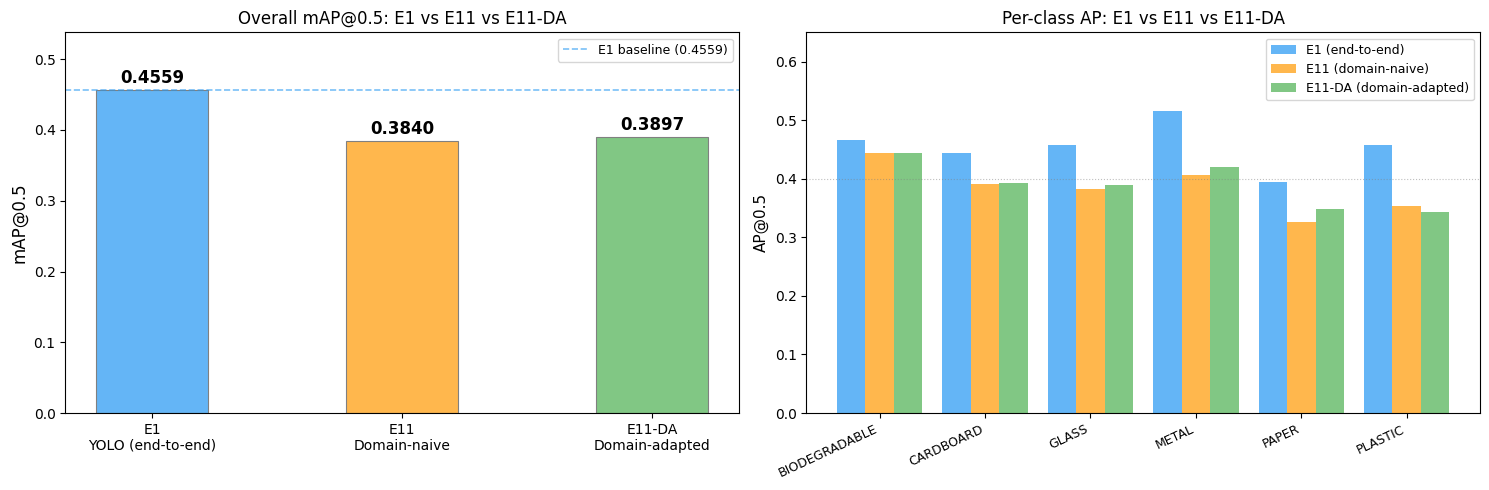

Saved: E11_DA_comparison.png


In [16]:

# ── CELL 13 ── Comparison plots

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: overall mAP bar chart
ax = axes[0]
exp_labels = ["E1\nYOLO (end-to-end)", "E11\nDomain-naive", "E11-DA\nDomain-adapted"]
map_vals   = [E1_MAP50, E11_MAP50, da_map50]
bar_colors = ["#64B5F6", "#FFB74D", "#81C784"]
bars       = ax.bar(exp_labels, map_vals, color=bar_colors, width=0.45,
                    edgecolor="gray", linewidth=0.8)
for bar, val in zip(bars, map_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.4f}", ha="center", va="bottom",
            fontsize=12, fontweight="bold")
ax.axhline(E1_MAP50, color="#2196F3", linestyle="--", linewidth=1.2,
           alpha=0.6, label=f"E1 baseline ({E1_MAP50})")
ax.set_ylabel("mAP@0.5", fontsize=12)
ax.set_ylim(0, max(map_vals) * 1.18)
ax.set_title("Overall mAP@0.5: E1 vs E11 vs E11-DA", fontsize=12)
ax.legend(fontsize=9)

# Right: per-class AP grouped bar chart
ax = axes[1]
x = np.arange(len(CLASS_NAMES))
w = 0.27

ax.bar(x - w, [E1_PER_CLASS[n] for n in CLASS_NAMES],    w,
       label="E1 (end-to-end)", color="#64B5F6")
ax.bar(x,     [E11_PER_CLASS[n] for n in CLASS_NAMES],   w,
       label="E11 (domain-naive)", color="#FFB74D")
ax.bar(x + w, [da_per_class_ap[i] for i in range(6)],    w,
       label="E11-DA (domain-adapted)", color="#81C784")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right", fontsize=9)
ax.set_ylabel("AP@0.5", fontsize=11)
ax.set_title("Per-class AP: E1 vs E11 vs E11-DA", fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 0.65)
ax.axhline(0.40, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "E11_DA_comparison.png"), dpi=150)
plt.show()
print("Saved: E11_DA_comparison.png")


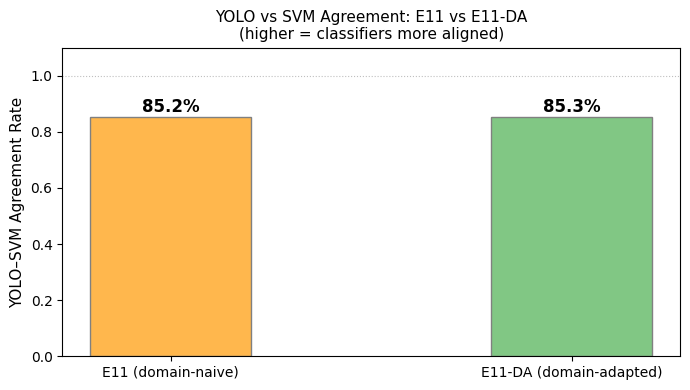

Saved: E11_DA_agreement_rate.png


In [17]:

# ── CELL 14 ── Domain shift analysis — agreement rate comparison
# Original E11: 85.2% agreement   DA E11: ?
# A higher agreement rate means the DA-SVM agrees more with YOLO
# (not necessarily better — but tells you if the classifiers now see the world similarly)

fig, ax = plt.subplots(figsize=(7, 4))

agree_rates = {
    "E11 (domain-naive)": 0.8522,
    "E11-DA (domain-adapted)": agree_rate,
}

bars = ax.bar(list(agree_rates.keys()), list(agree_rates.values()),
              color=["#FFB74D", "#81C784"], width=0.4, edgecolor="gray")
for bar, val in zip(bars, agree_rates.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{val*100:.1f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_ylabel("YOLO–SVM Agreement Rate", fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title("YOLO vs SVM Agreement: E11 vs E11-DA\n"
             "(higher = classifiers more aligned)", fontsize=11)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "E11_DA_agreement_rate.png"), dpi=150)
plt.show()
print("Saved: E11_DA_agreement_rate.png")



In [18]:

# ── CELL 15 ── Save results to detection_results.csv
det_csv = os.path.join(RESULTS_DIR, "detection_results.csv")

new_row = {
    "experiment":          "E11_DA",
    "model":               "TwoStage_YOLO+DA_HybridSVM",
    "timestamp":           datetime.now().strftime("%Y-%m-%d %H:%M"),
    "map50":               round(da_map50,  4),
    "map50_95":            "",
    "precision":           "",
    "recall":              "",
    "fps":                 "",
    "model_size_mb":       "",
    "epochs_trained":      "",
    "image_size":          640,
    "feature_dim":         508,
    "map50_BIODEGRADABLE": round(da_per_class_ap[0], 4),
    "map50_CARDBOARD":     round(da_per_class_ap[1], 4),
    "map50_GLASS":         round(da_per_class_ap[2], 4),
    "map50_METAL":         round(da_per_class_ap[3], 4),
    "map50_PAPER":         round(da_per_class_ap[4], 4),
    "map50_PLASTIC":       round(da_per_class_ap[5], 4),
    "svm_yolo_agree_rate": round(agree_rate, 4),
    "n_boxes":             total_det,
}

if os.path.isfile(det_csv):
    df_det = pd.read_csv(det_csv)
    df_det = df_det[df_det["experiment"] != "E11_DA"]
    df_det = pd.concat([df_det, pd.DataFrame([new_row])], ignore_index=True)
else:
    df_det = pd.DataFrame([new_row])

df_det.to_csv(det_csv, index=False)
print(f"Saved → {det_csv}")
print(f"\n{'='*55}")
print(f"  E11-DA complete")
print(f"  mAP@0.5 = {da_map50:.4f}")
print(f"  Δ vs E1  ({E1_MAP50}) = {delta_vs_e1:+.4f}")
print(f"  Δ vs E11 ({E11_MAP50}) = {delta_vs_e11:+.4f}")
print(f"  YOLO/DA-SVM agreement = {agree_rate*100:.1f}%")
print(f"{'='*55}")


Saved → /Users/nadaashraf/Desktop/CV-Project/results/metrics/detection_results.csv

  E11-DA complete
  mAP@0.5 = 0.3897
  Δ vs E1  (0.4559) = -0.0662
  Δ vs E11 (0.384) = +0.0057
  YOLO/DA-SVM agreement = 85.3%
